Installing Libraries
1. pandas + numpy

→ Load + clean data

2. matplotlib + seaborn + plotly

→ Understand data visually

3. sklearn + xgboost + lightgbm

→ Train prediction models

4. imbalanced-learn

→ Fix failure rarity problem

5. statsmodels + tsfresh

→ Deep time-series understanding

6. tqdm + pyarrow

→ Performance optimization

In Our Model:
Normal > 99%
failure< 1%
so model will learn to predict normal all the times, and acheive 99% success...
For this problem we will use imbalance-learn, it will do oversampling(create more failure examples(SMOTE (Synthetic Minority Over-sampling Technique))) 
or
Undersampling  (reduce normal data) 



In [ ]:
%pip install numpy pandas matplotlib seaborn scikit-learn scipy
%pip install plotly tqdm pyarrow
%pip install xgboost lightgbm
%pip install imbalanced-learn
%pip install statsmodels tsfresh

In [5]:
# =========================
# CORE LIBRARIES
# =========================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Utilities
from tqdm import tqdm

# Settings
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully 🚀")

Libraries loaded successfully 🚀


In [6]:
file_path = "D:\PredictiveMaintainance\dataset\MetroPT3(AirCompressor).csv"

sample_df = pd.read_csv(file_path, nrows=5)

sample_df

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\Muhammad Hassan\AppData\Local\Temp\ipykernel_9060\2294761686.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  file_path = "D:\PredictiveMaintainance\dataset\MetroPT3(AirCompressor).csv"


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [8]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       5 non-null      int64  
 1   timestamp        5 non-null      str    
 2   TP2              5 non-null      float64
 3   TP3              5 non-null      float64
 4   H1               5 non-null      float64
 5   DV_pressure      5 non-null      float64
 6   Reservoirs       5 non-null      float64
 7   Oil_temperature  5 non-null      float64
 8   Motor_current    5 non-null      float64
 9   COMP             5 non-null      float64
 10  DV_eletric       5 non-null      float64
 11  Towers           5 non-null      float64
 12  MPG              5 non-null      float64
 13  LPS              5 non-null      float64
 14  Pressure_switch  5 non-null      float64
 15  Oil_level        5 non-null      float64
 16  Caudal_impulses  5 non-null      float64
dtypes: float64(15), int64(1), str(1

In [9]:
sample_df.columns

Index(['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses'],
      dtype='str')

In [10]:
dtypes = {
    'TP2': 'float32',
    'TP3': 'float32',
    'H1': 'float32',
    'DV_pressure': 'float32',
    'Reservoirs': 'float32',
    'Motor_current': 'float32',
    'Oil_temperature': 'float32',

    'COMP': 'int8',
    'DV_eletric': 'int8',
    'TOWERS': 'int8',
    'MPG': 'int8',
    'LPS': 'int8',
    'Pressure_switch': 'int8',
    'Oil_level': 'int8',
    'Caudal_impulses': 'int16'
}

In [11]:
df = pd.read_csv(
    file_path,
    dtype=dtypes,
    parse_dates=['timestamp']
)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Unnamed: 0       1516948 non-null  int64         
 1   timestamp        1516948 non-null  datetime64[us]
 2   TP2              1516948 non-null  float32       
 3   TP3              1516948 non-null  float32       
 4   H1               1516948 non-null  float32       
 5   DV_pressure      1516948 non-null  float32       
 6   Reservoirs       1516948 non-null  float32       
 7   Oil_temperature  1516948 non-null  float32       
 8   Motor_current    1516948 non-null  float32       
 9   COMP             1516948 non-null  int8          
 10  DV_eletric       1516948 non-null  int8          
 11  Towers           1516948 non-null  float64       
 12  MPG              1516948 non-null  int8          
 13  LPS              1516948 non-null  int8          
 14  Pressure_swit

In [13]:
# =========================
# REMOVE USELESS COLUMN
# =========================

df.drop(columns=['Unnamed: 0'], inplace=True)

# =========================
# RENAME COLUMNS
# =========================

df.rename(columns={
    'DV_eletric': 'DV_electric',
    'Towers': 'TOWERS'
}, inplace=True)

# =========================
# CONVERT TIMESTAMP
# =========================

df['timestamp'] = pd.to_datetime(df['timestamp'])

# =========================
# SORT CHRONOLOGICALLY
# =========================

df.sort_values('timestamp', inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaning completed ✅")

Cleaning completed ✅


In [14]:
df.sample(5)

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_electric,TOWERS,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
1436518,2020-08-20 11:05:14,-0.014,9.914,9.902,-0.018,9.912,71.625000,3.7850,1,0,1.0,1,0,1,0,1
523570,2020-04-12 06:22:14,-0.016,8.720,8.708,-0.024,8.722,54.375000,0.0400,1,0,1.0,1,0,1,1,1
1421352,2020-08-18 07:01:42,-0.012,9.630,9.620,-0.022,9.630,67.824997,3.7175,1,0,1.0,1,0,1,1,1
594914,2020-04-22 03:36:59,-0.016,8.620,8.610,-0.026,8.620,49.224998,0.0425,1,0,1.0,1,0,1,1,1
569489,2020-04-18 19:12:59,8.994,8.848,-0.006,2.002,8.850,73.550003,5.8000,0,1,0.0,0,0,1,1,1


In [15]:
print(df.shape)

(1516948, 16)


In [16]:
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_electric,TOWERS,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.599998,0.0400,1,0,1.0,1,0,1,1,1
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.674999,0.0400,1,0,1.0,1,0,1,1,1
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.599998,0.0425,1,0,1.0,1,0,1,1,1
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.424999,0.0400,1,0,1.0,1,0,1,1,1
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.474998,0.0400,1,0,1.0,1,0,1,1,1


In [17]:
df.describe()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_electric,TOWERS,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,1516948,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06
mean,2020-05-16 22:58:36.631517,1.367826e+00,8.984611e+00,7.568155e+00,5.595620e-02,8.985233e+00,6.264418e+01,2.050171e+00,8.369568e-01,1.606106e-01,9.198483e-01,8.326640e-01,3.420025e-03,9.914368e-01,9.041556e-01,9.371066e-01
min,2020-02-01 00:00:00,-3.200000e-02,7.300000e-01,-3.600000e-02,-3.200000e-02,7.120000e-01,1.540000e+01,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2020-03-23 05:05:04.500000,-1.400000e-02,8.492000e+00,8.254000e+00,-2.200000e-02,8.494000e+00,5.777500e+01,4.000000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,2020-05-17 08:07:06,-1.200000e-02,8.960000e+00,8.784000e+00,-2.000000e-02,8.960000e+00,6.270000e+01,4.500000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,2020-07-10 03:07:27.500000,-1.000000e-02,9.492000e+00,9.374000e+00,-1.800000e-02,9.492000e+00,6.725000e+01,3.807500e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,2020-09-01 03:59:50,1.067600e+01,1.030200e+01,1.028800e+01,9.844000e+00,1.030000e+01,8.905000e+01,9.295000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,3.250930e+00,6.390951e-01,3.333200e+00,3.824015e-01,6.383070e-01,6.516261e+00,2.302053e+00,3.694052e-01,3.671716e-01,2.715280e-01,3.732757e-01,5.838091e-02,9.214078e-02,2.943779e-01,2.427712e-01


In [18]:
print("Start:", df['timestamp'].min())
print("End:", df['timestamp'].max())

Start: 2020-02-01 00:00:00
End: 2020-09-01 03:59:50


In [19]:
df.isnull().sum()

timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_electric        0
TOWERS             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

In [21]:
df.to_parquet(r"D:\PredictiveMaintainance\dataset\MetroPT3_cleaned.parquet")

In [22]:
df = pd.read_parquet(
    r"D:\PredictiveMaintainance\dataset\MetroPT3_cleaned.parquet"
)

In [23]:
df.shape

(1516948, 16)

In [24]:
df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_electric,TOWERS,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.599998,0.0400,1,0,1.0,1,0,1,1,1
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.674999,0.0400,1,0,1.0,1,0,1,1,1
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.599998,0.0425,1,0,1.0,1,0,1,1,1
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.424999,0.0400,1,0,1.0,1,0,1,1,1
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.474998,0.0400,1,0,1.0,1,0,1,1,1


In [25]:
# =========================
# BASIC DATASET INFO
# =========================

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(1516948, 16)

Columns:
Index(['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
       'Oil_temperature', 'Motor_current', 'COMP', 'DV_electric', 'TOWERS',
       'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses'],
      dtype='str')

Data Types:
timestamp          datetime64[us]
TP2                       float32
TP3                       float32
H1                        float32
DV_pressure               float32
Reservoirs                float32
Oil_temperature           float32
Motor_current             float32
COMP                         int8
DV_electric                  int8
TOWERS                    float64
MPG                          int8
LPS                          int8
Pressure_switch              int8
Oil_level                    int8
Caudal_impulses             int16
dtype: object

Missing Values:
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temper

In [26]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,1516948,2020-05-16 22:58:36.631517,2020-02-01 00:00:00,2020-03-23 05:05:04.500000,2020-05-17 08:07:06,2020-07-10 03:07:27.500000,2020-09-01 03:59:50,NaN
TP2,1516948.0,1.367826,-0.032,-0.014,-0.012,-0.01,10.676,3.25093
TP3,1516948.0,8.984611,0.73,8.492,8.96,9.492,10.302,0.639095
H1,1516948.0,7.568155,-0.036,8.254,8.784,9.374,10.288,3.3332
DV_pressure,1516948.0,0.055956,-0.032,-0.022,-0.02,-0.018,9.844,0.382402
Reservoirs,1516948.0,8.985233,0.712,8.494,8.96,9.492,10.3,0.638307
Oil_temperature,1516948.0,62.644184,15.4,57.775002,62.700001,67.25,89.050003,6.516261
Motor_current,1516948.0,2.050171,0.02,0.04,0.045,3.8075,9.295,2.302053
COMP,1516948.0,0.836957,0.0,1.0,1.0,1.0,1.0,0.369405
DV_electric,1516948.0,0.160611,0.0,0.0,0.0,0.0,1.0,0.367172


Visualizations

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

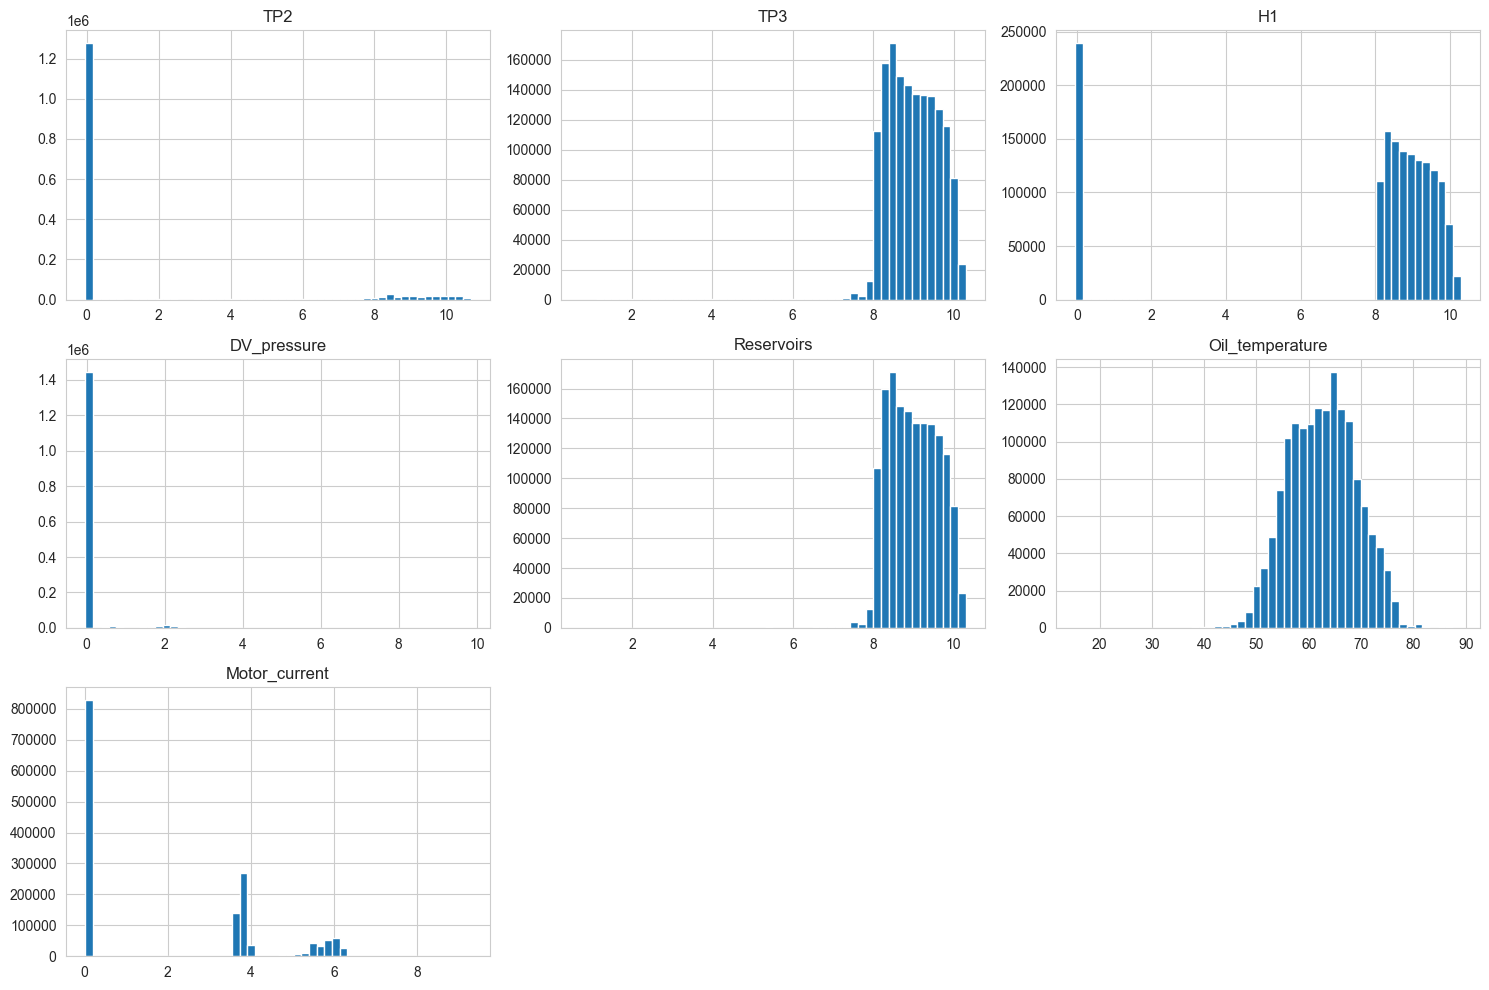

In [28]:
important_features = [
    'TP2',
    'TP3',
    'H1',
    'DV_pressure',
    'Reservoirs',
    'Oil_temperature',
    'Motor_current'
]

df[important_features].hist(
    figsize=(15, 10),
    bins=50
)

plt.tight_layout()
plt.show()

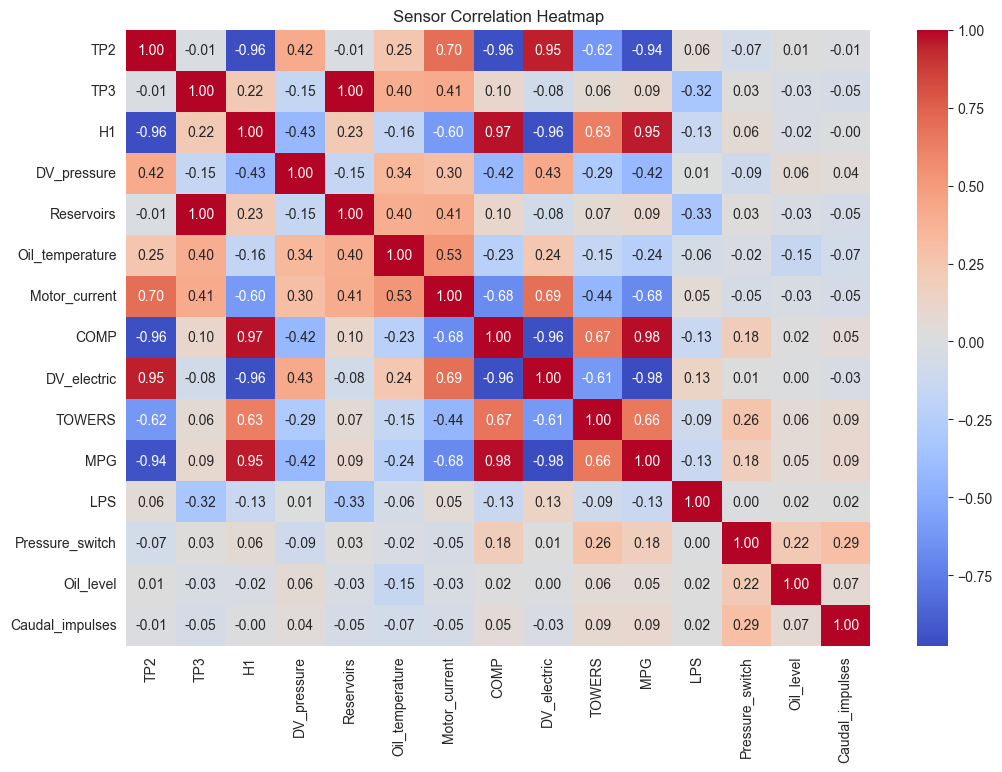

In [29]:
plt.figure(figsize=(12, 8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Sensor Correlation Heatmap")
plt.show()

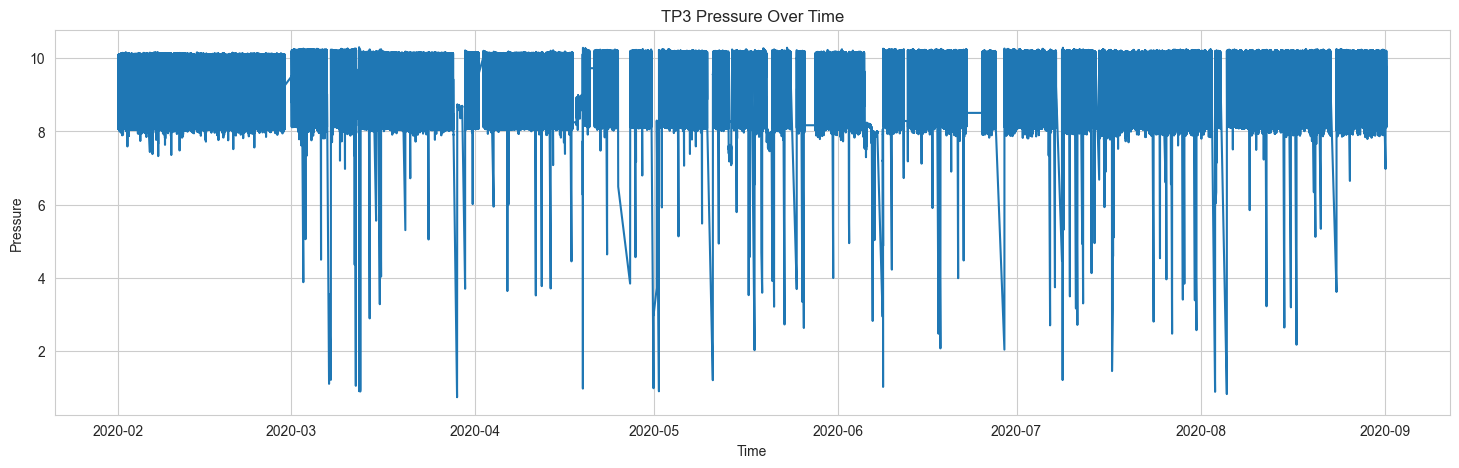

In [30]:
plt.figure(figsize=(18, 5))

plt.plot(df['timestamp'], df['TP3'])

plt.title("TP3 Pressure Over Time")
plt.xlabel("Time")
plt.ylabel("Pressure")

plt.show()

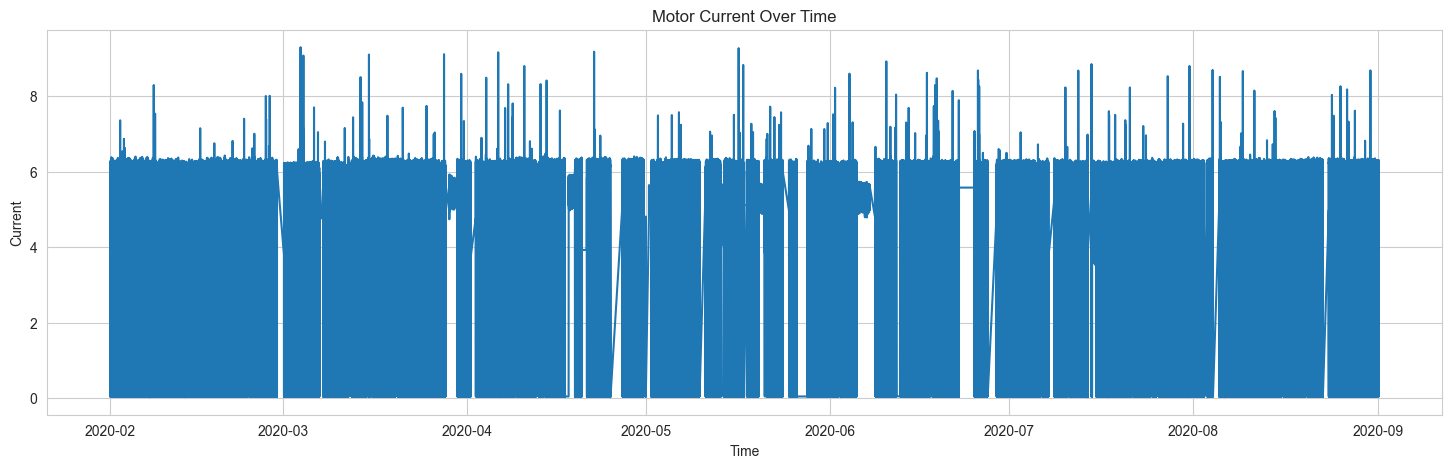

In [31]:
plt.figure(figsize=(18, 5))

plt.plot(df['timestamp'], df['Motor_current'])

plt.title("Motor Current Over Time")
plt.xlabel("Time")
plt.ylabel("Current")

plt.show()